# 232. Implement Queue using Stacks
https://leetcode.com/problems/implement-queue-using-stacks/

## Complexity Comparison

| Approach | Push | Pop (amortized) | Peek (amortized) | Notes |
|----------|------|-----------------|-------------------|-------|
| Two stacks (lazy transfer) | $O(1)$ | $O(1)$ | $O(1)$ | Optimal amortized |
| Two stacks (eager transfer) | $O(n)$ | $O(1)$ | $O(1)$ | Transfer on every push |

## Methodology

Use two stacks: `inStack` for pushes and `outStack` for pops/peeks. Push always goes to `inStack`. When popping or peeking, if `outStack` is empty, transfer all elements from `inStack` to `outStack` (reversing their order). This gives amortized O(1) for all operations since each element is moved at most twice.

## Solutions

### C#

In [ ]:
public class MyQueue {
    private Stack<int> inStack = new();
    private Stack<int> outStack = new();

    public void Push(int x) => inStack.Push(x);

    public int Pop() { Transfer(); return outStack.Pop(); }

    public int Peek() { Transfer(); return outStack.Peek(); }

    public bool Empty() => inStack.Count == 0 && outStack.Count == 0;

    private void Transfer() {
        if (outStack.Count == 0)
            while (inStack.Count > 0)
                outStack.Push(inStack.Pop());
    }
}

### Python

In [ ]:
class MyQueue:
    def __init__(self):
        self.in_stack = []
        self.out_stack = []

    def push(self, x: int) -> None:
        self.in_stack.append(x)

    def pop(self) -> int:
        self._transfer()
        return self.out_stack.pop()

    def peek(self) -> int:
        self._transfer()
        return self.out_stack[-1]

    def empty(self) -> bool:
        return not self.in_stack and not self.out_stack

    def _transfer(self):
        if not self.out_stack:
            while self.in_stack:
                self.out_stack.append(self.in_stack.pop())

### Go

In [ ]:
type MyQueue struct {
    inStack  []int
    outStack []int
}

func Constructor() MyQueue {
    return MyQueue{}
}

func (q *MyQueue) Push(x int) {
    q.inStack = append(q.inStack, x)
}

func (q *MyQueue) transfer() {
    if len(q.outStack) == 0 {
        for len(q.inStack) > 0 {
            n := len(q.inStack)
            q.outStack = append(q.outStack, q.inStack[n-1])
            q.inStack = q.inStack[:n-1]
        }
    }
}

func (q *MyQueue) Pop() int {
    q.transfer()
    n := len(q.outStack)
    val := q.outStack[n-1]
    q.outStack = q.outStack[:n-1]
    return val
}

func (q *MyQueue) Peek() int {
    q.transfer()
    return q.outStack[len(q.outStack)-1]
}

func (q *MyQueue) Empty() bool {
    return len(q.inStack) == 0 && len(q.outStack) == 0
}

### Rust

In [ ]:
struct MyQueue {
    in_stack: Vec<i32>,
    out_stack: Vec<i32>,
}

impl MyQueue {
    fn new() -> Self {
        MyQueue { in_stack: Vec::new(), out_stack: Vec::new() }
    }

    fn push(&mut self, x: i32) {
        self.in_stack.push(x);
    }

    fn transfer(&mut self) {
        if self.out_stack.is_empty() {
            while let Some(val) = self.in_stack.pop() {
                self.out_stack.push(val);
            }
        }
    }

    fn pop(&mut self) -> i32 {
        self.transfer();
        self.out_stack.pop().unwrap()
    }

    fn peek(&mut self) -> i32 {
        self.transfer();
        *self.out_stack.last().unwrap()
    }

    fn empty(&self) -> bool {
        self.in_stack.is_empty() && self.out_stack.is_empty()
    }
}

## Example Scenarios

1. **Common Case** — Basic push-then-pop sequence  
   **Input:** `push(1), push(2), peek(), pop(), empty()`  
   After two pushes, `inStack = [1,2]`. Peek triggers transfer to `outStack = [2,1]` (reversed), so peek returns $1$. Pop returns $1$. `empty()` returns `false` since `outStack` still has $[2]$.

2. **Slightly Complex** — Interleaved push and pop  
   **Input:** `push(1), push(2), pop(), push(3), pop(), pop()`  
   After push(1), push(2): `inStack=[1,2]`. Pop transfers → `outStack=[2,1]`, pops $1$. Push(3): `inStack=[3]`, `outStack=[2]`. Pop returns $2$ from outStack. Pop transfers $[3]$ → `outStack=[3]`, pops $3$.

3. **Edge Case: Time Factor** — Worst-case amortized transfer  
   **Input:** `push(1), push(2), ..., push(n), pop()`  
   After $n$ pushes, inStack has $n$ elements. The first pop transfers all $n$ elements to outStack in $O(n)$. But the next $n-1$ pops are each $O(1)$, giving amortized $O(1)$ per operation.

4. **Edge Case: Space Factor** — All elements in both stacks  
   **Input:** `push(1), push(2), pop(), push(3), push(4)`  
   After pop: `outStack=[2]`, then push(3), push(4): `inStack=[3,4]`. Both stacks hold elements simultaneously: total space is always $O(n)$ where $n$ is the number of elements in the queue.

5. **Almost-Impossible but Plausible** — 100 operations stress test  
   **Input:** 100 interleaved push/pop/peek/empty calls  
   With up to 100 operations, each stack can hold at most 100 elements. The amortized guarantee holds: each element is transferred at most once from inStack to outStack. Total work across all operations is $O(100)$, not $O(100^2)$.

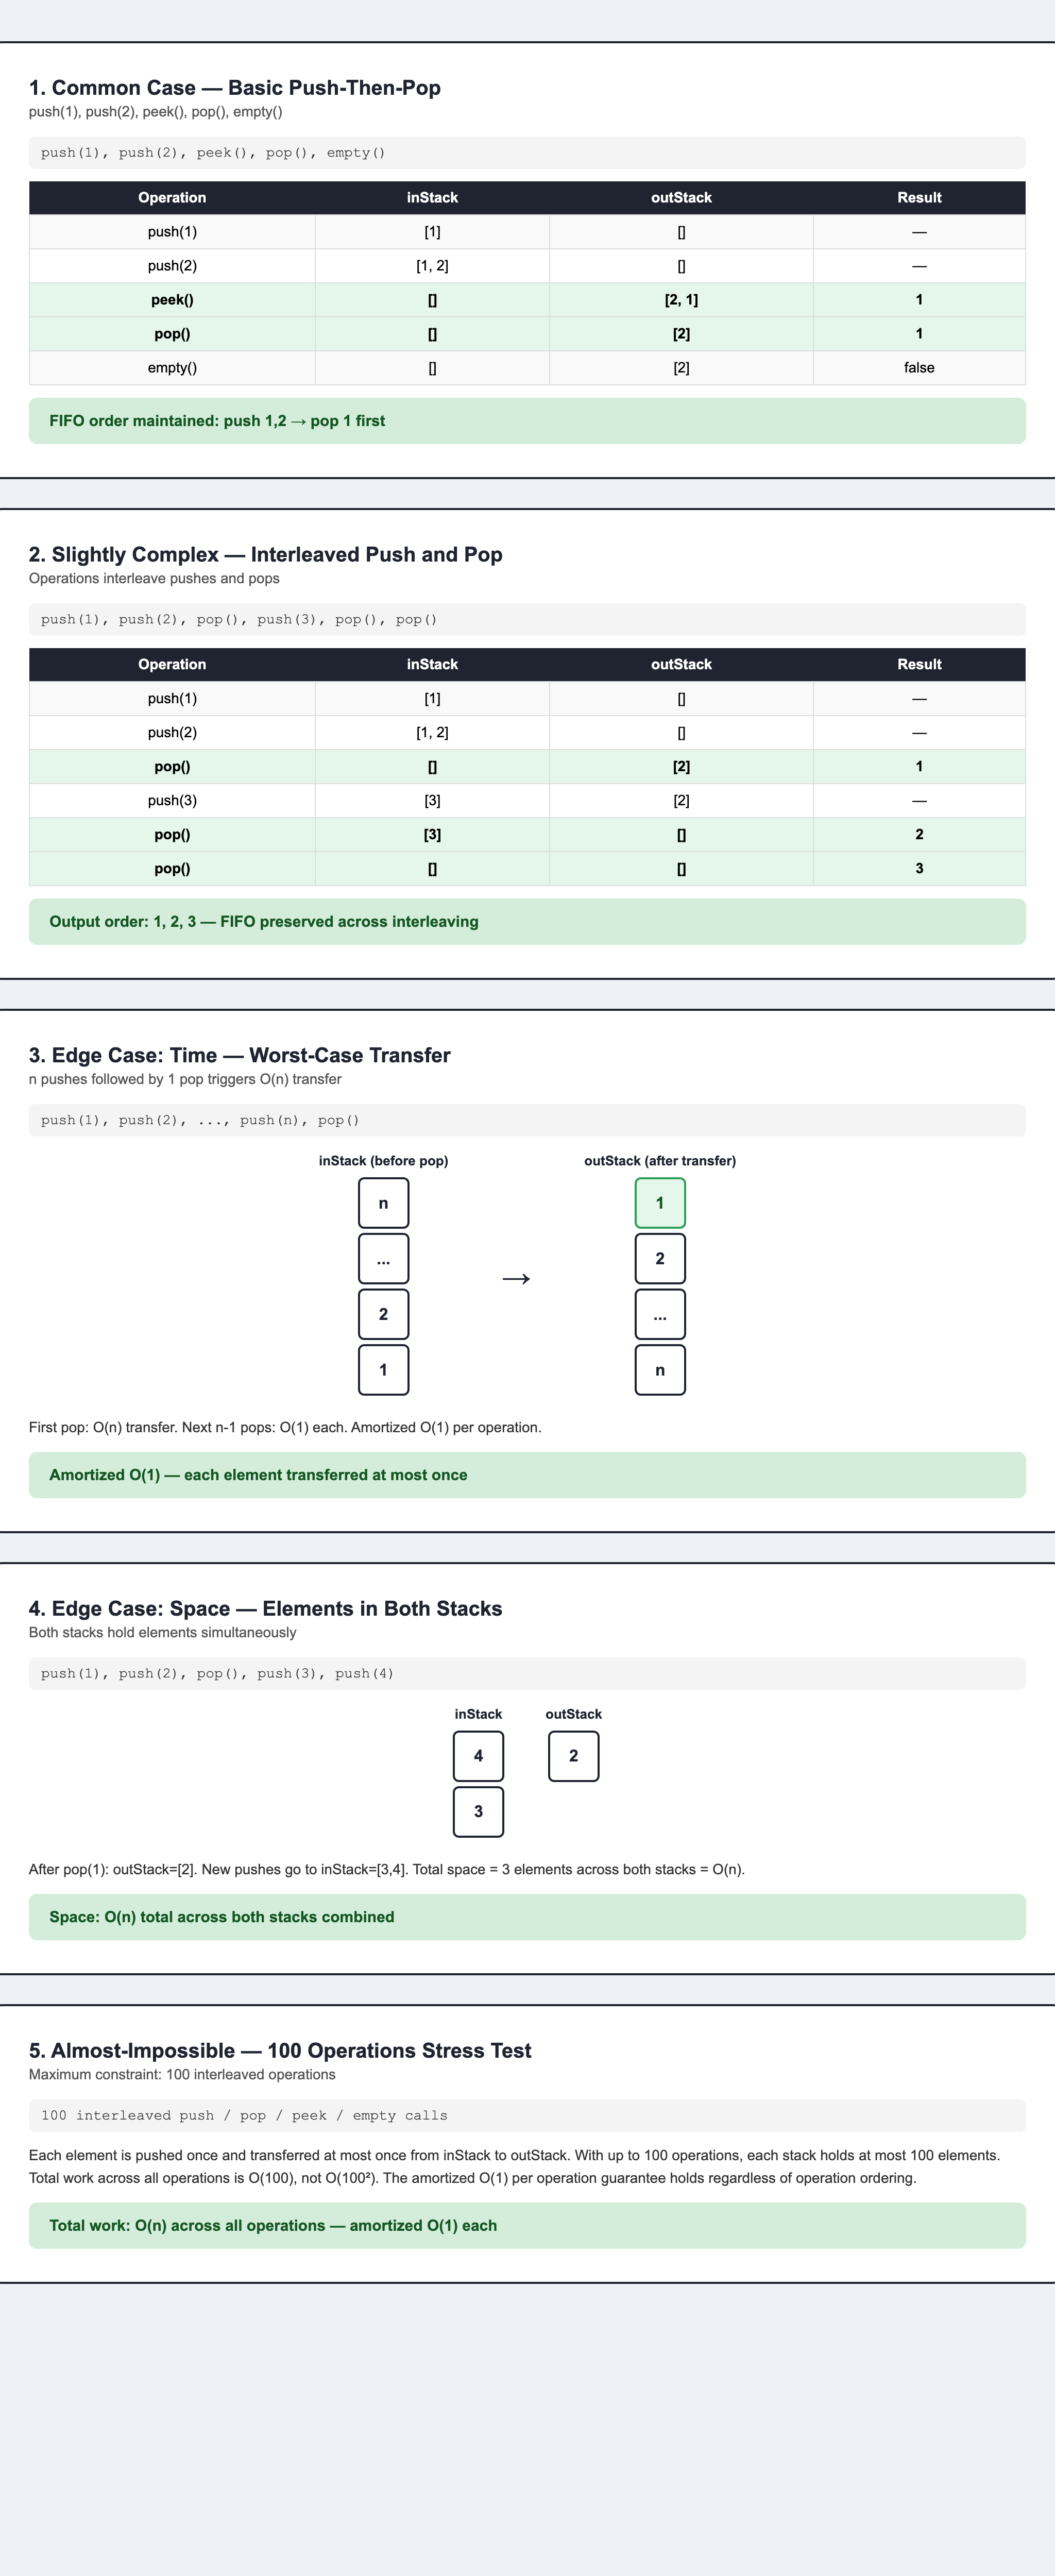